<div style="background: linear-gradient(to bottom, #F566BA, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Captioned Icons — Exploration
Browses `data/icons_captioned.jsonl`: one randomly drawn monochrome static icon per path-count tier (1–5 paths), showing its Iconify ID alongside short and long captions.

</div>

In [13]:
import io
import json
import random
import re
import sys
import textwrap
from pathlib import Path

import cairosvg
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
from PIL import Image

sys.path.insert(0, "..")
from brand import blue

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "text.color":       "black",
    "font.family":      "sans-serif",
    "figure.dpi":       150,
})

_ANIM_RE = re.compile(r'<animate|<set[\s>/]|@keyframes|animation\s*:', re.IGNORECASE)

DATA = Path("../data/icons_captioned.jsonl")
records = []
with open(DATA) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

eligible = [
    r for r in records
    if not r["is_multicolor"] and not _ANIM_RE.search(r["svg"])
]

print(f"Captioned icons loaded : {len(records):,}")
print(f"Monochrome + static    : {len(eligible):,}")

Captioned icons loaded : 162,775
Monochrome + static    : 158,128


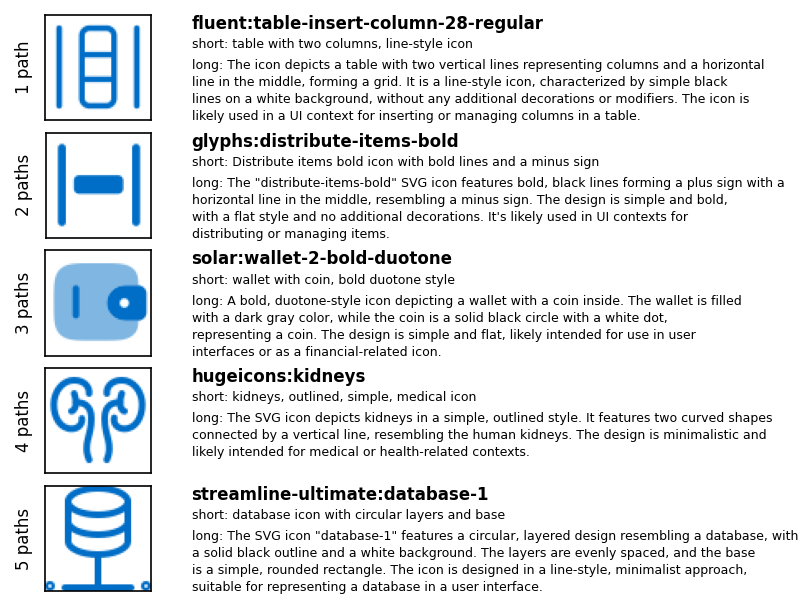

In [22]:
def _render(svg_str: str, size: int = 100) -> np.ndarray:
    colored = re.sub(r'currentColor', '#006EC7', svg_str, flags=re.IGNORECASE)
    png = cairosvg.svg2png(
        bytestring=colored.encode(),
        output_width=size,
        output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

def _icon_border(ax, lw=4):
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.add_patch(FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.05",
        linewidth=lw,
        edgecolor=blue,
        facecolor="none",
        transform=ax.transAxes,
        clip_on=False,
        zorder=10,
    ))


n_paths_rows = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(
    len(n_paths_rows), 2,
    figsize=(7.0, 4.0),
    facecolor="white",
    gridspec_kw={"width_ratios": [1, 4]},
)
fig.subplots_adjust(left=0.12, right=0.85, top=0.98, bottom=0.02, hspace=0.12, wspace=0.05)

for row_i, n_paths in enumerate(n_paths_rows):
    pool = [r for r in eligible if int(r["path_count"]) == n_paths]

    # — icon column —
    ax_img = axes[row_i, 0]
    ax_img.set_facecolor("white")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    ax_img.set_aspect("equal", anchor="N")
    #_icon_border(ax_img)
    ax_img.set_ylabel(
        f"{n_paths} path{'s' if n_paths > 1 else ''}",
        color="black", fontsize=8, labelpad=6,
    )

    # — text column —
    ax_txt = axes[row_i, 1]
    ax_txt.set_facecolor("white")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)
    ax_txt.set_xticks([])
    ax_txt.set_yticks([])
    for sp in ax_txt.spines.values():
        sp.set_visible(False)

    if not pool:
        ax_img.text(0.5, 0.5, "no data", ha="center", va="center",
                    color=blue, fontsize=8, transform=ax_img.transAxes)
        ax_txt.text(0.01, 0.5, "no captioned icons with this path count",
                    ha="left", va="center", color="black", fontsize=9,
                    transform=ax_txt.transAxes)
        continue

    r = random.choice(pool)
    ax_img.imshow(_render(r["svg"], size=64))

    short = r.get("caption_short", "")
    long_ = "\n".join(textwrap.wrap(r.get("caption_long", ""), width=90))

    ax_txt.text(0, 1, r["icon_id"],
                ha="left", va="top", color="black",
                fontsize=8, fontweight="bold",
                transform=ax_txt.transAxes)
    ax_txt.text(0, 0.78, "short: " + short,
                ha="left", va="top", color="black",
                fontsize=6,
                transform=ax_txt.transAxes)
    ax_txt.text(0, 0.58, "long: " + long_,
                ha="left", va="top", color="black",

                fontsize=6, linespacing=1.4,
                transform=ax_txt.transAxes)
plt.savefig("output/icon_caption_examples.png", dpi=300, bbox_inches="tight")
plt.show()